# Creating a looping graph



In [78]:
from langgraph.graph import StateGraph, START, END
from dataclasses import dataclass, field

In [79]:
@dataclass
class AgentState:
    name : str = ""
    nums : list[int] = field(default_factory=list)
    counter : int = 0
    msg : str = ""

In [80]:
def greeting(state: AgentState)-> AgentState:
    state.msg = f"hi {state.name}, welcome to this loop"

    return state

def random_node(state: AgentState)-> AgentState:
    
    if state.counter < 5 :
        state.counter+=1

    return state

def routing_logic(state: AgentState) -> str:
    if state.counter < 5 :
        state.nums.append(state.counter)
        print(f"Print turn {state.counter}")
        return "loop"

    else:
        return "Exit"


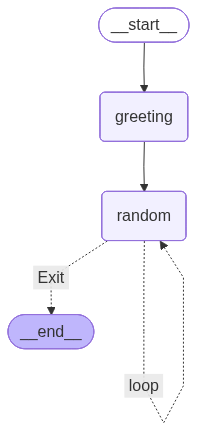

In [81]:
graph = StateGraph(AgentState)

graph.add_node("greeting",greeting)
graph.add_node("random",random_node)

graph.add_edge(START,"greeting")
graph.add_edge("greeting","random")


graph.add_conditional_edges(
    "random",
    routing_logic,
    {
        "loop":"random",
        "Exit": END
    }
)

app = graph.compile()

from IPython.display import Image,display 
display(Image(app.get_graph().draw_mermaid_png()))


In [82]:
print(app.invoke({"name":"aaditya"}))

Print turn 1
Print turn 2
Print turn 3
Print turn 4
{'name': 'aaditya', 'nums': [1, 2, 3, 4], 'counter': 5, 'msg': 'hi aaditya, welcome to this loop'}


# Higher or lower game


In [83]:
import random 

@dataclass
class GameState:
    name: str =""
    message : str = ""
    guess: list[int] = field(default_factory=list)
    attempts: int = 0
    lower_bound: int = 0
    upper_bound: int = 20
    target: int = 0
    hint : str = ""



def setup_node(state: GameState)-> GameState:
    '''is an init node for few state vars '''
    state.message = f'Hi {state.name}, shall we play a game??'
    state.hint = f'This is a hint start playing'
    state.target = random.randint(0,20)

    return state

def guess_node(state: GameState) -> GameState:
    '''does the guessing of the number'''
    guess_pool = [i for i in range(state.lower_bound, state.upper_bound) if i not in state.guess]

    if guess_pool:
        guess = random.choice(guess_pool)
    else :
        guess = random.randint(state.lower_bound, state.upper_bound)

    state.guess.append(guess)
    state.attempts +=1

    print(f'Guess number {state.attempts}, attempt ans = {state.guess[-1]}, target:{state.target}, {state.hint}')

    return state


def hint_node(state: GameState)-> GameState:
    '''gives hints based on guess'''
    if state.target == state.guess[-1]:
        state.hint = f"Number found end game {state.guess[-1]}"


    elif state.target < state.guess[-1]:
        state.hint = f"hint : guess is higher than target {state.guess[-1]}"
        state.upper_bound= min(state.guess[-1], state.upper_bound)

    elif state.target > state.guess[-1]:
        state.hint = f"hint: guess is lower than target {state.guess[-1]}"
        state.lower_bound = max(state.guess[-1], state.lower_bound)


    return state


def should_continue_node(state: GameState)-> str:
    '''Continuing if num is not found'''

    if state.guess[-1] == state.target:
        print(f'number found: {state.target} exiting ....')
        return "exit"

    elif state.attempts == 7:
        return "exit"

    elif state.attempts < 7 :
        return "loop"

  

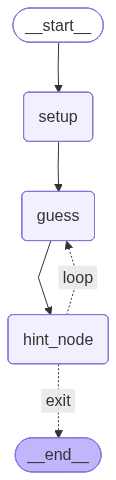

In [84]:
graph2 = StateGraph(GameState)

graph2.add_node("setup",setup_node)
graph2.add_node("guess",guess_node)
graph2.add_node("hint_node",hint_node)

graph2.add_edge(START, "setup")
graph2.add_edge("setup","guess")
graph2.add_edge("guess", "hint_node")


graph2.add_conditional_edges(
    "hint_node",
    should_continue_node,
    {
        "loop":"guess",
        "exit": END
    }
)


app = graph2.compile()

from IPython.display import Image,display 
display(Image(app.get_graph().draw_mermaid_png()))




In [85]:
print(app.invoke({"name":"Aaditya"}))

Guess number 1, attempt ans = 6, target:19, This is a hint start playing
Guess number 2, attempt ans = 7, target:19, hint: guess is lower than target 6
Guess number 3, attempt ans = 14, target:19, hint: guess is lower than target 7
Guess number 4, attempt ans = 16, target:19, hint: guess is lower than target 14
Guess number 5, attempt ans = 18, target:19, hint: guess is lower than target 16
Guess number 6, attempt ans = 19, target:19, hint: guess is lower than target 18
number found: 19 exiting ....
{'name': 'Aaditya', 'message': 'Hi Aaditya, shall we play a game??', 'guess': [6, 7, 14, 16, 18, 19], 'attempts': 6, 'lower_bound': 18, 'upper_bound': 20, 'target': 19, 'hint': 'Number found end game 19'}
